<a href="https://colab.research.google.com/github/ODBapp/2025_NODASS_workshop/blob/main/src/odb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/ODBapp/2025_NODASS_workshop.git

Cloning into '2025_NODASS_workshop'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (199/199), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 199 (delta 46), reused 52 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (199/199), 108.81 MiB | 19.17 MiB/s, done.
Resolving deltas: 100% (46/46), done.


# 地理資訊

In [ ]:
%cd 2025_NODASS_workshop/src/geo

[Errno 2] No such file or directory: '2025_NODASS_workshop/src/geo'
/content/2025_NODASS_workshop/src/geo


In [ ]:
import csv, json
import xml.etree.ElementTree as ET

In [ ]:
# === 轉換時間為ISO8601 ===
def toISO8601(datetime_string):
    return datetime_string.strip().replace('/', '-').replace(' ', 'T')

In [ ]:
# === GeoJSON輸出 ===
def export_geojson(out_path, coords, pt_properties=None, line=True, line_properties=None):
    pt_properties = pt_properties or []
    line_properties = line_properties or {}

    features = []
    for idx, coord in enumerate(coords):
        props = pt_properties[idx] if idx < len(pt_properties) else {}
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": coord},
            "properties": props
        })

    if line:
        features.append({
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": coords
            },
            "properties": line_properties
        })

    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    with open(out_path, 'w', encoding='utf-8') as f:
        # json.dump(geojson, f) # 無排版，檔案較小(15KB)
        json.dump(geojson, f, indent=2) # 排版，檔案較大 (30KB)

In [ ]:
# === KML輸出 ===
def export_kml(out_path, coords, pt_descriptions=None, pt_names=None, line=True, line_properties=None, line_name='線段'):
    pt_descriptions = pt_descriptions or []
    pt_names = pt_names or []
    line_properties = line_properties or {}

    kml = ET.Element("kml", xmlns="http://www.opengis.net/kml/2.2")
    document = ET.SubElement(kml, "Document")

    names = pt_names
    if len(coords) > len(names):
        names = [str(i + 1) for i in range(len(coords))]

    for idx, coord in enumerate(coords):
        placemark = ET.SubElement(document, "Placemark")
        ET.SubElement(placemark, "name").text = names[idx]
        if idx < len(pt_descriptions):
            ET.SubElement(placemark, "description").text = pt_descriptions[idx]

        point = ET.SubElement(placemark, "Point")
        ET.SubElement(point, "coordinates").text = f"{coord[0]},{coord[1]}"

    if line:
        placemark = ET.SubElement(document, "Placemark")
        ET.SubElement(placemark, "name").text = line_name
        ET.SubElement(placemark, "description").text = line_properties

        linestring = ET.SubElement(placemark, "LineString")
        ET.SubElement(linestring, "tessellate").text = "1"
        coords_text = ' '.join(f"{coord[0]},{coord[1]}" for coord in coords)
        ET.SubElement(linestring, "coordinates").text = coords_text

    ET.indent(kml, space="  ") # 排版方便閱讀，但檔案大小增加 (17KB vs 22KB)
    ET.ElementTree(kml).write(out_path, encoding='utf-8-sig', xml_declaration=True)

In [ ]:
# === 路徑檔名設定 ===
csv_path = '202507021522_export_GDP_22943_result.csv'
geojson_path = 'output.json'
kml_path = 'output.kml'

# === 讀取CSV ===
coords = []
times = []
json_pt_properties = []
kml_descriptions = []
total_sst = 0.0
count = 0

with open(csv_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        try:
            lon = float(row['CenterLongitude'])
            lat = float(row['CenterLatitude'])
            time = toISO8601(row['time'])
            sst = float(row['sst'])

            coords.append([lon, lat])
            times.append(time)
            json_pt_properties.append({"time": time, "sst": sst})
            kml_descriptions.append(f"SST: {sst}<br/>lon: {lon}<br/>lat: {lat}")

            total_sst += sst
            count += 1
        except (ValueError, KeyError):
            continue

In [ ]:
# 加入線段資料
mean_sst = round(10* total_sst / count) / 10

json_ln_properties = {
    "start": times[0],
    "end": times[-1],
    "sst_avg": mean_sst
}
kml_ln_properties = (
    f"Start: {times[0]}<br/>"
    f"End: {times[-1]}<br/>"
    f"Mean SST: {mean_sst}"
)

In [ ]:
# 輸出
export_geojson(geojson_path, coords, json_pt_properties, True, json_ln_properties)
export_kml(kml_path, coords, kml_descriptions, [], True, kml_ln_properties, 'GDP軌跡')

# 時間序列

In [ ]:
%cd 2025_NODASS_workshop/src/timeseries

# 海洋熱浪

In [3]:
%cd 2025_NODASS_workshop/src/mhw

/content/2025_NODASS_workshop/src/mhw


In [10]:
# 全球海洋熱浪資料計算
from datetime import datetime # https://docs.python.org/3/library/datetime.html # 時間格式與處理
import xarray # https://docs.xarray.dev/en/stable/ # for processing .nc files
import numpy as np # https://numpy.org/ # 處理list
import pandas as pd # https://pandas.pydata.org/ # 資料讀取分析
import requests #https://requests.readthedocs.io/en/latest/ # 下載資料
#import wget # https://www.gnu.org/software/wget/ # 下載資料
import re # https://docs.python.org/3/library/re.html # 正規表達式
import os # https://docs.python.org/3/library/os.html # 處理檔案與路徑等
import matplotlib.pyplot as plt # https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html # 畫圖

In [ ]:
# === step 0: 取得海溫資料 (從 NOAA 下載每日資料 nc 檔) ===

# 此範例是一次下載一個月的資料

# 我選擇時間的邏輯是當下時間的前一個月
#now = datetime.now()
#month_now = int(now.strftime('%m'))
#year_now = int(now.strftime('%Y'))
#if (month_now > 1):
#    month_now = str(month_now - 1).zfill(2) # 個位數的話補0(ex.2，補零，變成02)
#else:
#    year_now =year_now -1 # 如果是 1 月，想下載的資料會是，去年的 12 月
#    month_now = '12'

# NOAA的檔案網址
#url =f'https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/{year_now}{month_now}/'

# 設定路徑
# 若你是在自己電腦而非在colab，特別是在 Windows 要改變路徑的寫法
#working_dir = "/home/yeh/thermal/"

# 你存每日.nc檔的地方
#OISST_dir = os.path.join(working_dir, 'OISST/')
#print('開始判斷資料夾')
# 判斷 OISST 這個要存 .nc 檔的資料夾是否存在，若不存在就建一個 OISST 為名的資料夾
#if os.path.exists(OISST_Dir):
#    pass
#    print('資料夾存在')
#else:
#    os.makedirs(OISST_Dir, exist_ok=True)
#
# 檢查 url 這個變數內的網址是否為一個檔案，若是一個檔案就不會以"/"結束
# isFile function
#def isFile(url):
#    if url.endswith('/'):
#        return False
#    else:
#        return True

# 把要下載的 nc file 放在一個 list 內
# get_url function
#def get_url(base_url):
#    text = ''
#    try:
        # html into text
#        text=requests.get(base_url).text
#    except Exception as e:
#        print("error - > ",base_url,e)
#        pass
#    reg = '<a href="(.*?)">.*</a>'
#    urls = [base_url + url for url in re.findall(reg, text) if url != '../']
#    files=[]
#    for i in urls:
#        if i.endswith('nc'):
#            files.append(i)
#    return files

# 下載
# 先檢查url是否為一個檔案(用 function isFile)
# 如果是一個檔案
# 把檔案名字取出
# 檢查此檔案是否已存在資料夾
# 若沒有
# 用 wget 下載
#def get_file(url):
#    if isFile(url):
#        try:
#            full_name = url.split('//')[-1]
#            filename = full_name.split('/')[-1]
#            path_filename = OISST_Dir  + filename
#            if os.path.isfile(path_filename):
#                print(f'{filename} 存在')
#                pass
#            else:
#                wget.download(url,OISST_Dir)
#        except:
#            pass
#    else:
#        urls = get_url(url)
#        for u in urls:
#            get_file(u)

#get_file(url)


In [ ]:
# 說明 xarray 讀取 .nc 檔
ds0 = xarray.open_dataset("./data/oisst-avhrr-v02r01.20250501.nc")
print(ds0) # 印出資料表頭（包含變數、維度、屬性等基本資訊）

# 補充
#print(ds0.attrs) # 印出整份資料的 metadata 屬性

#for key, value in ds0.attrs.items():
#    print(f"{key}: {value}")

#for key, value in ds0['anom'].attrs.items(): # Climatology is based on 1971-2000 OI.v2 SST.
#    print(f"{key}: {value}")

#ds0['ice']

#print(ds0['sst'].shape) # 維度

#print(ds0['sst'].values) # 實際值
#每個list長度是1440


In [7]:
# === step 1: 計算每個格點每個月的平均海表溫度 (Monthly Mean SST) ===

# 指定要處理的年份
year = '2025'

# 組合該年所有檔案的路徑
file_path = f'./data/*{year}*.nc'

# 開啟多個 NetCDF 檔案並合併為一個資料集（使用 dask 平行處理）
ds = xarray.open_mfdataset(file_path, parallel=True, chunks={'time': '500MB'})

# 對時間進行重取樣（resample）為每月（'1MS' = 每月第一天），並取月平均
mean_month_sst = ds["sst"].resample(time='1MS').mean().compute()

# 清除極值（e.g., 大於 100°C 的值當作錯誤資料）
mean_month_sst = mean_month_sst.where(mean_month_sst <= 100)

# 顯示結果：每個月、每個格點的平均海溫（緯度 x 經度，720 x 1440）
#mean_month_sst
#mean_month_sst.shape

(2, 1, 720, 1440)

In [8]:
# === step 2: SST 遮罩 (去除冰區與陸地) ===

# 參數：定義海冰遮罩條件（每月內超過幾天有冰就排除）
ndays_ice = 15
# === (1) 製作海冰遮罩 ===
ice = ds.ice.fillna(0)  # 把 NaN 補成 0，代表該格點當天沒有冰
ice_binary = xarray.where(ice <= 0, 0, 1)  # 有冰（>0%）設為 1，沒冰設為 0
ice_days_per_month = ice_binary.resample(time='1MS').sum(dim='time')  # 統計每個月內冰天數
ice_mask = xarray.where(ice_days_per_month > ndays_ice, 1, 0)  # 若該月冰天數超過 15 天 → 遮罩值設為 1，否則為 0

# === (2) 載入並調整陸地遮罩 ===
lsm = xarray.open_dataset('./data/lsmask.oisst.v2.nc') # NOAA 下載
lsm = -lsm["lsmask"] + 1  # 調整為：0 = 海洋, 1 = 陸地
# 補充排除區域：五大湖與 Lake Ponchartrain
lsm = lsm.where(~((lsm.lon >= 267) & (lsm.lon < 285) & (lsm.lat >= 41) & (lsm.lat <= 50)), 1)
lsm = lsm.where(~((lsm.lon >= 269.5) & (lsm.lon < 270.5) & (lsm.lat >= 30) & (lsm.lat <= 31)), 1)

# === (3) 套用遮罩條件到每月 SST ===
masked_sst = mean_month_sst.copy()  # 複製一份資料用來存結果

for i in range(mean_month_sst.time.size):
    # 取出第 i 個月的 SST 與冰遮罩
    sst_slice = mean_month_sst.isel(time=i)
    ice_slice = ice_mask.isel(time=i)

    # 套用 land mask（lsm == 0 表示海洋）
    temp = sst_slice.where(lsm == 0, np.nan)

    # 套用 ice mask（ice_mask == 0 表示該月沒有冰 ）
    # （符合條件的水域 & 沒有冰）兩者都滿足才保留，否則設為 np.nan
    temp = temp.where(ice_slice == 0, np.nan)

    temp = temp.squeeze(drop=True)  # 移除多餘維度

    # 存回對應時間點的 masked SST
    masked_sst[i, :, :] = temp.values


Text(0.5, 1.0, 'masked SST')

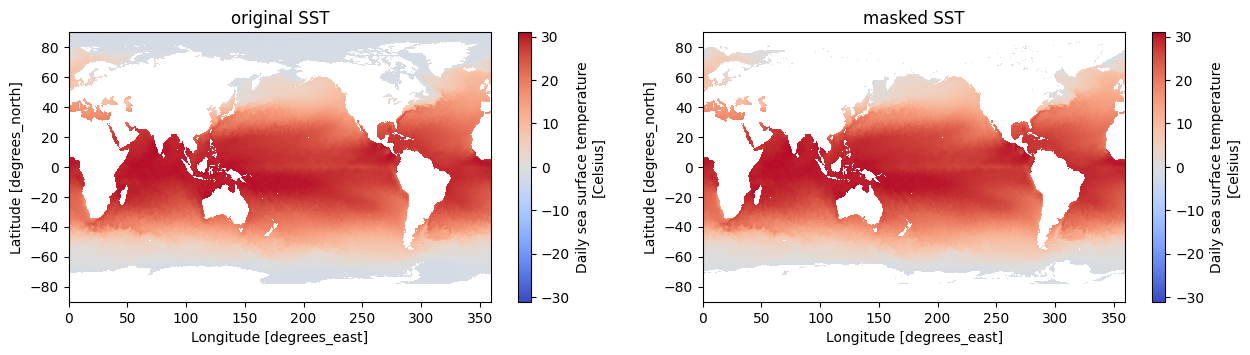

In [17]:
# 比較未遮罩 / 已遮罩的 SST 地圖

fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))
cmap = plt.get_cmap('coolwarm')
mean_month_sst.isel(time=0).squeeze().plot(ax=axes[0],cmap=cmap)
axes[0].set_title("original SST")

masked_sst.isel(time=0).squeeze().plot(ax=axes[1],cmap=cmap)
axes[1].set_title("masked SST")

# xarray.plot() 沒有畫真實地圖背景、也沒有地圖投影概念，只是用來「快速預覽資料」
# 只是資料分佈圖

In [16]:
# === step 3: 計算距平值 (SST Anomaly) ===
# 距平值 = 當月海溫 - 長期氣候平均海溫

# 讀入 1982–2011 的長期氣候平均月海溫（April + May 兩個月的氣候值已經預先儲存）
sst_clim = xarray.open_dataset('./data/oisst_sst_clim_1982-2011_April_May.nc')

# 取出 masked_sst 的時間對應的月份（轉成整數，例如 4, 5）
month_now = pd.to_datetime(masked_sst.time.values).month

# 使用 xarray 的 sel 方法，根據月份挑出對應的氣候平均值，再與當月觀測值相減
sst_an = masked_sst - sst_clim.sel(month=month_now)

# 改名
sst_an = sst_an.rename({'sst': 'sst_an'})

# 顯示資料結構
sst_an


<xarray.Dataset> Size: 33MB
Dimensions:  (lat: 720, lon: 1440, zlev: 1, month: 2, time: 2)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * zlev     (zlev) float32 4B 0.0
  * month    (month) int64 16B 4 5
  * time     (time) datetime64[ns] 16B 2025-04-01 2025-05-01
Data variables:
    sst_an   (time, zlev, lat, lon, month) float64 33MB nan nan nan ... nan nan

In [18]:
# 安裝畫地圖用的套件
# https://github.com/SciTools/cartopy
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 100.5 MB/s eta 0:00:00


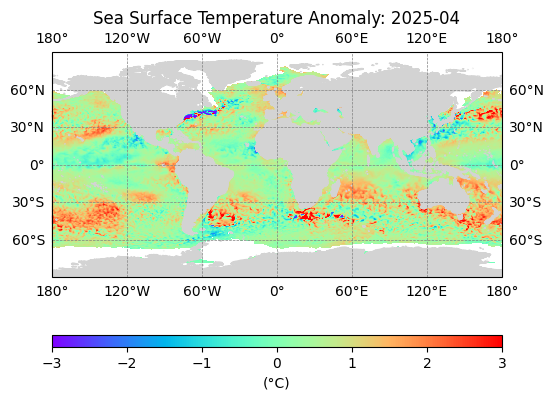

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 取出一個時間點的資料（假設只處理單月）
sst_an_1m = sst_an.sel(time='2025-04-01',month=4).squeeze()["sst_an"] # 去除 time, zlev 維度，只留下 (lat, lon)

# 建立圖形
fig = plt.figure(figsize=(9, 3),facecolor='w', edgecolor='k')
ax = plt.axes(projection=ccrs.PlateCarree())

# 畫海溫距平圖
pcm = sst_an_1m.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='rainbow',
    vmin=-3,
    vmax=3,
    add_colorbar=False,
    add_labels=False
)

ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                edgecolor='face',
                                                facecolor='lightgray'))

axins1 = inset_axes(ax, width="100%", height="5%", borderpad=-5, loc='lower center')
# 加 colorbar
cbar = fig.colorbar(pcm, ax=ax,orientation="horizontal",cax=axins1)
cbar.set_label('(°C)')
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
# 標題
plot_date = pd.to_datetime(sst_an.time.values[0]).strftime('%Y-%m')
# 經緯線
ax.set_title(f'Sea Surface Temperature Anomaly: {plot_date}', fontsize=12)

fig.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

# 生物資料

In [ ]:
%cd 2025_NODASS_workshop/src/bio